# DyslexAI — Notebook 01b: Crop Verification & Provenance Recovery

**Final Year Project — Software Engineering**
**Phase 2B | Handwriting modality | Jira: DYS-24, DYS-25, DYS-26**

---

## Why this notebook exists

Following supervisor review, padding was replaced with **manual ROI cropping**: every image in
Dataset A was cropped by hand to the written area only.

That solved the padding problem and created a new one.

### The problem

Notebook 01 found the dataset's duplicates by computing a **SHA-256 fingerprint** of each file
and grouping the matches. Files with identical bytes are exact copies.

Manual cropping changes the bytes. Two files that were byte-identical before cropping were
cropped by hand — slightly different rectangles — so afterwards they are no longer identical.

**The duplicates are still in the dataset. Our method for detecting them stopped working.**

| Measure | Original | Cropped |
|---|---|---|
| Files | 852 | 852 |
| Unique SHA-256 | 638 | 852 |
| Redundant copies detected | 214 | **0** |
| Cross-class conflicts detected | 48 | **0** |

If we ran Notebook 02 unchanged on the cropped images, it would find nothing to remove, report
a clean 852-image dataset, and every downstream result would be contaminated — **with no error
raised anywhere**.

### What this notebook does

1. Verifies the crops correspond one-to-one with the originals.
2. Demonstrates and quantifies the loss of hash-based detection.
3. **Recovers the duplicate structure from provenance** — the original audit — rather than
   re-deriving it from pixels.
4. Measures what cropping actually changed geometrically.
5. Produces a cropped-dataset metadata table carrying the provenance forward.

### The key idea

We do not try to re-detect duplicates in the cropped images. We **inherit** the answer.

Every cropped file kept its original filename. The original metadata table records, for every
one of those filenames, which duplicate group it belonged to. So we join on filename and carry
the group assignment across.

Provenance is recorded, not re-inferred. That is both more reliable and more defensible.

---

## Stage map

| Stage | Name |
|---|---|
| 0 | Setup — extract originals and crops |
| 1 | Verify one-to-one correspondence |
| 2 | Demonstrate the loss of hash-based detection |
| 3 | Recover duplicate structure from provenance |
| 4 | Measure what cropping changed |
| 5 | Visual comparison |
| 6 | Build the cropped metadata table |
| 7 | Report and supervisor log |

---
# STAGE 0 — Setup

### Before you run this

Upload both cropped archives to Drive alongside the original:

```
MyDrive/DyslexAI/archives/
├── Complete_And_Balance_Hand-written_Dataset.rar   ← original, keep
├── Cropped_No.zip
└── Cropped_Yes.zip
```

The original archive is still needed — this notebook compares against it.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, sys, json, random, subprocess, time, hashlib, re
from pathlib import Path
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image

# ---- Paths -----------------------------------------------------------------
DRIVE_ROOT   = Path('/content/drive/MyDrive')
PROJECT_DIR  = DRIVE_ROOT / 'DyslexAI'
ARCHIVE_DIR  = PROJECT_DIR / 'archives'
RAW_DIR      = Path('/content/raw')

INTERIM_DIR  = PROJECT_DIR / 'data' / 'interim'
REPORTS_DIR  = PROJECT_DIR / 'reports'
FIGURES_DIR  = PROJECT_DIR / 'results' / 'figures'

for d in [RAW_DIR, INTERIM_DIR, REPORTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

IMG_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

print('Archives present:')
for p in sorted(ARCHIVE_DIR.glob('*')):
    print(f'  {p.name:<55} {p.stat().st_size/1e6:>7.1f} MB')

Archives present:
  Complete_And_Balance_Hand-written_Dataset.rar              56.3 MB
  Cropped_No.zip                                              8.3 MB
  Cropped_Yes.zip                                             8.0 MB
  Dataset Dyslexia_Kaggle.rar                                78.9 MB
  Multilingual AI-Based Dyslexia Detection Mendely.rar       56.5 MB


### 0.1 Extract both versions

The original goes to `/content/raw/dataset_a_original`, the crops to
`/content/raw/dataset_a_cropped`. Local disk, disposable, rebuilt each session.

In [ ]:
!apt-get -qq install -y libarchive-tools > /dev/null 2>&1


def extract(archive_name: str, dest: Path):
    src = ARCHIVE_DIR / archive_name
    if not src.exists():
        raise FileNotFoundError(f'Not found: {src}')
    dest.mkdir(parents=True, exist_ok=True)
    subprocess.run(['bsdtar', '-xf', str(src), '-C', str(dest)],
                   capture_output=True, check=False)
    n = sum(1 for p in dest.rglob('*') if p.is_file())
    print(f'{archive_name:<50} -> {n} files')


ORIG_DIR = RAW_DIR / 'dataset_a_original'
CROP_DIR = RAW_DIR / 'dataset_a_cropped'

if not any(ORIG_DIR.rglob('*.jpeg')):
    extract('Complete_And_Balance_Hand-written_Dataset.rar', ORIG_DIR)
else:
    print('original already extracted')

if not any(CROP_DIR.rglob('*.jpeg')):
    extract('Cropped_No.zip', CROP_DIR)
    extract('Cropped_Yes.zip', CROP_DIR)
else:
    print('crops already extracted')

Complete_And_Balance_Hand-written_Dataset.rar      -> 852 files
Cropped_No.zip                                     -> 426 files
Cropped_Yes.zip                                    -> 852 files


### 0.2 Locate the image folders

The two cropped archives were zipped separately and do **not** share a folder layout — one
nests its images under an extra directory, the other does not. Rather than hard-coding either,
we search for the folder that actually contains a large number of images for each class.

This is the same "do not assume paths" rule as Notebook 01, applied to a messier input.

In [ ]:
def find_image_dir(root: Path, class_name: str, min_files: int = 100) -> Path:
    """Find the directory holding this class's images, wherever the zip put it.

    Matches a directory whose own name matches the class (case-insensitive) and
    which directly contains at least `min_files` images.
    """
    candidates = []
    for d in [root] + [p for p in root.rglob('*') if p.is_dir()]:
        n = sum(1 for f in d.iterdir()
                if f.is_file() and f.suffix.lower() in IMG_EXT)
        if n >= min_files and class_name.lower() in d.name.lower():
            candidates.append((n, d))

    if not candidates:
        raise FileNotFoundError(
            f'No directory for class {class_name!r} under {root} '
            f'with >= {min_files} images')

    candidates.sort(reverse=True)
    return candidates[0][1]


CROP_DIRS = {cls: find_image_dir(CROP_DIR, cls) for cls in ['No', 'Yes']}
ORIG_DIRS = {cls: find_image_dir(ORIG_DIR, cls) for cls in ['No', 'Yes']}

print('cropped:')
for cls, d in CROP_DIRS.items():
    n = sum(1 for f in d.iterdir() if f.suffix.lower() in IMG_EXT)
    print(f'  {cls:<4} {n:>4} images   {d}')
print('original:')
for cls, d in ORIG_DIRS.items():
    n = sum(1 for f in d.iterdir() if f.suffix.lower() in IMG_EXT)
    print(f'  {cls:<4} {n:>4} images   {d}')

cropped:
  No    426 images   /content/raw/dataset_a_cropped/Dataset_Cropped_No/No
  Yes   426 images   /content/raw/dataset_a_cropped/Yes
original:
  No    426 images   /content/raw/dataset_a_original/Complete And Balance Hand-written Dataset/Dataset/No
  Yes   426 images   /content/raw/dataset_a_original/Complete And Balance Hand-written Dataset/Dataset/Yes


### 0.3 Load the original audit

This table is the **provenance record**. It is the only place the duplicate structure still
exists, because the cropped files no longer carry it in their bytes.

In [ ]:
META_PATH = INTERIM_DIR / 'dataset_a_master_metadata.csv'
orig = pd.read_csv(META_PATH)

print(f'original metadata : {len(orig)} rows')
print(f'unique hashes     : {orig["sha256"].nunique()}')
print(f'duplicate groups  : {orig[orig.group_size > 1]["duplicate_group"].nunique()}')
print(f'conflict groups   : {orig[orig.group_n_classes > 1]["duplicate_group"].nunique()}')

original metadata : 852 rows
unique hashes     : 638
duplicate groups  : 147
conflict groups   : 20


---
# STAGE 1 — Verify One-to-One Correspondence

Before trusting anything else, confirm the crops actually match the originals: same count, same
filenames, nothing lost, nothing renamed, nothing added.

If a file went missing during cropping, every join afterwards would silently drop a row.

In [ ]:
def list_names(d: Path) -> set:
    return {f.name for f in d.iterdir()
            if f.is_file() and f.suffix.lower() in IMG_EXT}


rows = []
for cls in ['No', 'Yes']:
    o = list_names(ORIG_DIRS[cls])
    c = list_names(CROP_DIRS[cls])
    rows.append({
        'class'            : cls,
        'original_files'   : len(o),
        'cropped_files'    : len(c),
        'missing_from_crop': len(o - c),
        'extra_in_crop'    : len(c - o),
    })

corr = pd.DataFrame(rows)
print(corr.to_string(index=False))

# Report any mismatch by name rather than only by count
for cls in ['No', 'Yes']:
    o, c = list_names(ORIG_DIRS[cls]), list_names(CROP_DIRS[cls])
    if o - c:
        print(f'\n{cls}: MISSING from crops -> {sorted(o - c)[:10]}')
    if c - o:
        print(f'\n{cls}: EXTRA in crops -> {sorted(c - o)[:10]}')

assert corr['missing_from_crop'].sum() == 0, 'Some originals were not cropped'
assert corr['extra_in_crop'].sum() == 0, 'Crops contain files not in the original'
print('\nOne-to-one correspondence verified: every original has exactly one crop.')

class  original_files  cropped_files  missing_from_crop  extra_in_crop
   No             426            426                  0              0
  Yes             426            426                  0              0

One-to-one correspondence verified: every original has exactly one crop.


---
# STAGE 2 — The Loss of Hash-Based Detection

Now we measure the problem rather than assert it.

We hash every cropped file and compare the duplicate structure against the original. The
expectation: near-total loss of detection, because manual cropping guarantees different pixels.

In [ ]:
def sha256_of_file(path: Path, chunk: int = 1 << 20) -> str:
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        while True:
            b = f.read(chunk)
            if not b:
                break
            h.update(b)
    return h.hexdigest()


crop_rows = []
for cls, d in CROP_DIRS.items():
    for f in sorted(p for p in d.iterdir()
                    if p.is_file() and p.suffix.lower() in IMG_EXT):
        crop_rows.append({
            'original_filename': f.name,
            'class_label'      : cls,
            'relative_path'    : f'{cls}/{f.name}',
            'abs_path'         : str(f),
            'crop_sha256'      : sha256_of_file(f),
            'file_size_bytes'  : f.stat().st_size,
        })

crop = pd.DataFrame(crop_rows)
print(f'cropped files hashed: {len(crop)}')

comparison = pd.DataFrame([
    {'measure': 'files',                      'original': len(orig),
     'cropped': len(crop)},
    {'measure': 'unique SHA-256',             'original': orig['sha256'].nunique(),
     'cropped': crop['crop_sha256'].nunique()},
    {'measure': 'redundant copies detected',  'original': len(orig) - orig['sha256'].nunique(),
     'cropped': len(crop) - crop['crop_sha256'].nunique()},
    {'measure': 'cross-class identical files','original': int(orig['is_cross_class_conflict'].sum()),
     'cropped': int(crop.duplicated('crop_sha256', keep=False).sum())},
])
print()
print(comparison.to_string(index=False))

cropped files hashed: 852

                    measure  original  cropped
                      files       852      852
             unique SHA-256       638      852
  redundant copies detected       214        0
cross-class identical files        48        0


**Read that table carefully.**

The cropped dataset looks *clean*. Zero duplicates, zero conflicts, 852 distinct images.

It is not clean. It contains exactly the same duplicated source images and exactly the same
contradictory labels as before. The only thing that changed is our ability to see them.

This is worth remembering beyond this project: **a data-quality check that stops firing has not
necessarily stopped finding problems.** It may have stopped working.

---
# STAGE 3 — Recover the Structure from Provenance

### The join

Every cropped file kept its original filename, and filenames are unique within a class. So
`(class_label, original_filename)` identifies a file in both datasets, and we can carry the
original audit's group assignment across.

We join on that key and inherit:

- `duplicate_group` — which set of identical source files it came from
- `group_size` — how many copies that group had
- `group_n_classes` — whether the group spans both labels
- `is_cross_class_conflict` — the contradiction flag
- `orig_sha256` — the original content hash, kept for traceability

Nothing is inferred. Every value comes from the recorded audit.

In [ ]:
key = ['class_label', 'original_filename']

prov = orig[key + ['sha256', 'duplicate_group', 'group_size', 'group_n_classes',
                   'is_duplicate_copy', 'is_cross_class_conflict',
                   'width', 'height', 'capture_time', 'camera_model']].copy()
prov = prov.rename(columns={'sha256': 'orig_sha256',
                            'width' : 'orig_width',
                            'height': 'orig_height'})

merged = crop.merge(prov, on=key, how='left', validate='one_to_one')

unmatched = merged['duplicate_group'].isna().sum()
print(f'cropped files          : {len(merged)}')
print(f'matched to provenance  : {len(merged) - unmatched}')
print(f'UNMATCHED              : {unmatched}')

assert unmatched == 0, 'Some cropped files have no provenance record'
print('\nEvery cropped file carries its original duplicate-group assignment.')

cropped files          : 852
matched to provenance  : 852
UNMATCHED              : 0

Every cropped file carries its original duplicate-group assignment.


### 3.1 Verify the recovered structure

The recovered figures must match the original audit exactly. If they do not, the join is wrong
and nothing downstream can be trusted.

In [ ]:
recovered = pd.DataFrame([
    {'measure': 'files',
     'original audit': len(orig),
     'recovered': len(merged)},
    {'measure': 'distinct duplicate groups',
     'original audit': orig['duplicate_group'].nunique(),
     'recovered': merged['duplicate_group'].nunique()},
    {'measure': 'redundant copies',
     'original audit': len(orig) - orig['duplicate_group'].nunique(),
     'recovered': len(merged) - merged['duplicate_group'].nunique()},
    {'measure': 'cross-class conflict groups',
     'original audit': orig[orig.group_n_classes > 1]['duplicate_group'].nunique(),
     'recovered': merged[merged.group_n_classes > 1]['duplicate_group'].nunique()},
    {'measure': 'files in conflict groups',
     'original audit': int(orig['is_cross_class_conflict'].sum()),
     'recovered': int(merged['is_cross_class_conflict'].sum())},
])
print(recovered.to_string(index=False))

for _, r in recovered.iterrows():
    assert r['original audit'] == r['recovered'], f'Mismatch on {r["measure"]}'
print('\nAll recovered figures match the original audit exactly.')

                    measure  original audit  recovered
                      files             852        852
  distinct duplicate groups             638        638
           redundant copies             214        214
cross-class conflict groups              20         20
   files in conflict groups              48         48

All recovered figures match the original audit exactly.


### 3.2 Independent corroboration from filenames

The join above relies on the original metadata table. As a **second, independent check** we
derive the same two headline numbers from the cropped filenames alone, without touching the
original audit at all.

Two signatures survive cropping because filenames were preserved:

- the `1 (3).jpeg` copy-paste naming pattern, which marks the duplicated `No` images
- a filename appearing in **both** class folders, which marks a label contradiction

If these independently reproduce 194 and 20, the provenance recovery is corroborated by a route
that shares none of its assumptions.

In [ ]:
def filename_pattern(name: str) -> str:
    if re.match(r'^IMG_\d+', name):              return 'IMG_xxxx'
    if re.match(r'^\d{4}-\d{2}-\d{2} ', name):   return 'timestamp'
    if re.match(r'^\d+ \(\d+\)', name):         return 'copy_pattern'
    return 'other'


merged['filename_pattern'] = merged['original_filename'].map(filename_pattern)

print('filename pattern x class (cropped set):')
print(pd.crosstab(merged['filename_pattern'], merged['class_label']), '\n')

n_copy_pattern = (merged['filename_pattern'] == 'copy_pattern').sum()

names_no  = set(merged.query('class_label == "No"')['original_filename'])
names_yes = set(merged.query('class_label == "Yes"')['original_filename'])
shared    = names_no & names_yes

print(f'copy-pattern filenames (expect 194) : {n_copy_pattern}')
print(f'filenames in BOTH classes (expect 20): {len(shared)}')
print(f'  examples: {sorted(shared)[:6]}')

assert n_copy_pattern == 194, 'Copy-pattern count does not match the original audit'
assert len(shared) == 20, 'Cross-class filename count does not match the original audit'
print('\nBoth figures reproduce independently of the original metadata table.')

filename pattern x class (cropped set):
class_label        No  Yes
filename_pattern          
IMG_xxxx          134  198
copy_pattern      194    0
other               0    1
timestamp          98  227 

copy-pattern filenames (expect 194) : 194
filenames in BOTH classes (expect 20): 20
  examples: ['IMG_0185.jpeg', 'IMG_0186.jpeg', 'IMG_0187.jpeg', 'IMG_0188.jpeg', 'IMG_0193.jpeg', 'IMG_0194.jpeg']

Both figures reproduce independently of the original metadata table.


---
# STAGE 4 — What Cropping Actually Changed

Cropping was introduced to remove blank area. Here we measure how much it removed, and what it
did to image geometry — because that directly affects the preprocessing decision in Notebook 03.

In [ ]:
dims = []
for r in merged.itertuples():
    with Image.open(r.abs_path) as im:
        w, h = im.size
    dims.append({'crop_width': w, 'crop_height': h})

merged = pd.concat([merged.reset_index(drop=True), pd.DataFrame(dims)], axis=1)

merged['orig_area']   = merged['orig_width'] * merged['orig_height']
merged['crop_area']   = merged['crop_width'] * merged['crop_height']
merged['area_kept']   = merged['crop_area'] / merged['orig_area']
merged['orig_aspect'] = merged['orig_width'] / merged['orig_height']
merged['crop_aspect'] = merged['crop_width'] / merged['crop_height']

print('AREA RETAINED AFTER CROPPING')
print(f'  median : {merged["area_kept"].median()*100:.1f}%')
print(f'  mean   : {merged["area_kept"].mean()*100:.1f}%')
print(f'  min    : {merged["area_kept"].min()*100:.1f}%')
print(f'  max    : {merged["area_kept"].max()*100:.1f}%')
print()
print('ASPECT RATIO')
print(f'  original : {merged["orig_aspect"].min():.2f} to {merged["orig_aspect"].max():.2f}  '
      f'(median {merged["orig_aspect"].median():.2f})')
print(f'  cropped  : {merged["crop_aspect"].min():.2f} to {merged["crop_aspect"].max():.2f}  '
      f'(median {merged["crop_aspect"].median():.2f})')
print()
print('DIMENSIONS')
print(f'  original width  {merged["orig_width"].min()}-{merged["orig_width"].max()}, '
      f'height {merged["orig_height"].min()}-{merged["orig_height"].max()}')
print(f'  cropped  width  {merged["crop_width"].min()}-{merged["crop_width"].max()}, '
      f'height {merged["crop_height"].min()}-{merged["crop_height"].max()}')

AREA RETAINED AFTER CROPPING
  median : 20.6%
  mean   : 25.1%
  min    : 1.2%
  max    : 86.5%

ASPECT RATIO
  original : 0.25 to 2.17  (median 1.01)
  cropped  : 0.18 to 3.64  (median 0.96)

DIMENSIONS
  original width  119-1232, height 124-1291
  cropped  width  20-885, height 33-861


### What this means for preprocessing

Cropping removed a large share of each image — that was the point, and it directly addresses
the concern that padding gave the model irrelevant blank area to learn from.

But look at the **aspect ratio range**. Tight cropping follows the shape of the written
character, so the range of shapes gets *wider*, not narrower.

That matters for the next decision. Resizing a very wide or very tall image directly to a square
stretches it. The more extreme the aspect ratio, the more distortion. So removing padding did
not remove the problem — it traded a padding artefact for a shape distortion.

Neither option is free:

| Approach | Cost |
|---|---|
| Pad to square, then resize | Blank area the model may learn from |
| Resize directly to square | Character shape distorted, worse at extreme ratios |

Notebook 03 follows the direction and resizes directly, with no padding. It also
records the distortion each image receives, so the cost is documented rather than assumed — and
it sets up a controlled comparison of the two approaches as a separate experiment.

In [ ]:
# How many images would be badly distorted by a direct square resize?
merged['distortion'] = merged['crop_aspect'].apply(lambda a: max(a, 1/a))

for t in [1.5, 2.0, 3.0]:
    n = (merged['distortion'] > t).sum()
    print(f'images stretched more than {t}x by a direct square resize : '
          f'{n:>4}  ({100*n/len(merged):.1f}%)')

print()
print('worst 5:')
print(merged.nlargest(5, 'distortion')[
    ['class_label', 'original_filename', 'crop_width', 'crop_height', 'distortion']
].to_string(index=False))

images stretched more than 1.5x by a direct square resize :  255  (29.9%)
images stretched more than 2.0x by a direct square resize :   74  (8.7%)
images stretched more than 3.0x by a direct square resize :   13  (1.5%)

worst 5:
class_label        original_filename  crop_width  crop_height  distortion
        Yes 2024-02-04 16.10.45.jpeg          42          235    5.595238
        Yes 2024-02-26 23.16.38.jpeg          98          521    5.316327
        Yes 2024-02-04 16.47.08.jpeg          52          259    4.980769
        Yes            IMG_0252.jpeg          27          117    4.333333
        Yes            IMG_0302.jpeg          36          146    4.055556


---
# STAGE 5 — Visual Comparison

Numbers confirm the crops exist. Looking at them confirms they are *correct* — that the ROI
captured the written character and did not clip a stroke or an Urdu dot.

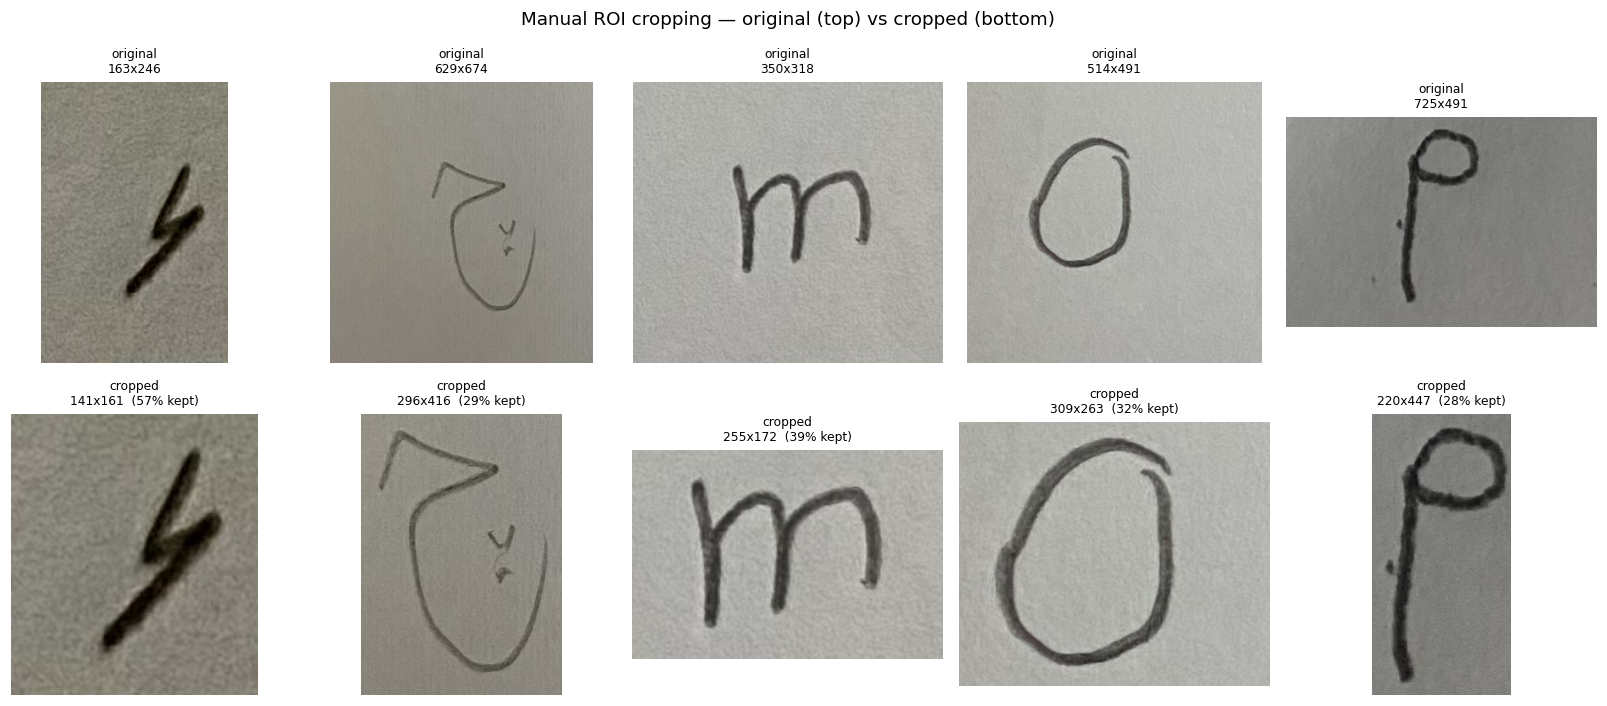

[saved] /content/drive/MyDrive/DyslexAI/results/figures/A_crop_comparison.png


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110

FIG = FIGURES_DIR


def compare_grid(rows_df, title, filename, n=5):
    fig, axes = plt.subplots(2, n, figsize=(3*n, 6.5))
    for col, r in enumerate(rows_df.head(n).itertuples()):
        orig_path = Path(ORIG_DIRS[r.class_label]) / r.original_filename
        axes[0, col].imshow(Image.open(orig_path))
        axes[0, col].set_title(f'original\n{r.orig_width}x{r.orig_height}', fontsize=8)
        axes[0, col].axis('off')

        axes[1, col].imshow(Image.open(r.abs_path))
        axes[1, col].set_title(f'cropped\n{r.crop_width}x{r.crop_height}  '
                               f'({100*r.area_kept:.0f}% kept)', fontsize=8)
        axes[1, col].axis('off')

    fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    fig.savefig(FIG / filename, bbox_inches='tight')
    plt.show()
    print(f'[saved] {FIG / filename}')


np.random.seed(SEED)
sample = merged.sample(5, random_state=SEED)
compare_grid(sample, 'Manual ROI cropping — original (top) vs cropped (bottom)',
             'A_crop_comparison.png')

### 5.1 The most aggressive crops

The images where the least area was kept are where clipping is most likely. Check that the
character is complete — including dots, which carry meaning in Urdu.

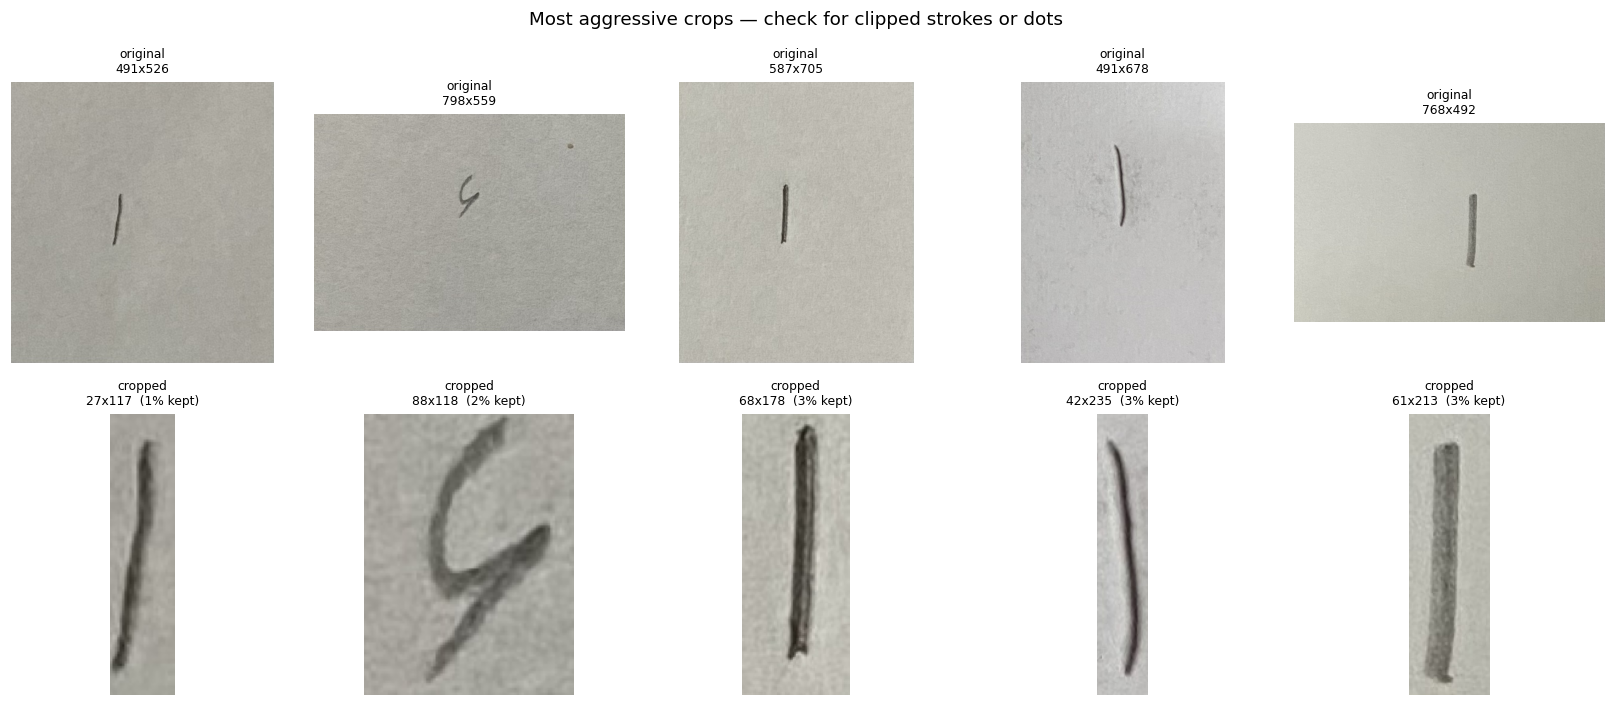

[saved] /content/drive/MyDrive/DyslexAI/results/figures/A_crop_most_aggressive.png


In [ ]:
compare_grid(merged.nsmallest(5, 'area_kept'),
             'Most aggressive crops — check for clipped strokes or dots',
             'A_crop_most_aggressive.png')

### 5.2 A cross-class conflict, before and after

These are the 20 files stored under both labels. Before cropping they were byte-identical.
After cropping they are two independently drawn rectangles of the same photograph — visibly the
same handwriting, different pixels.

This is the clearest possible illustration of why hash-based detection stopped working.

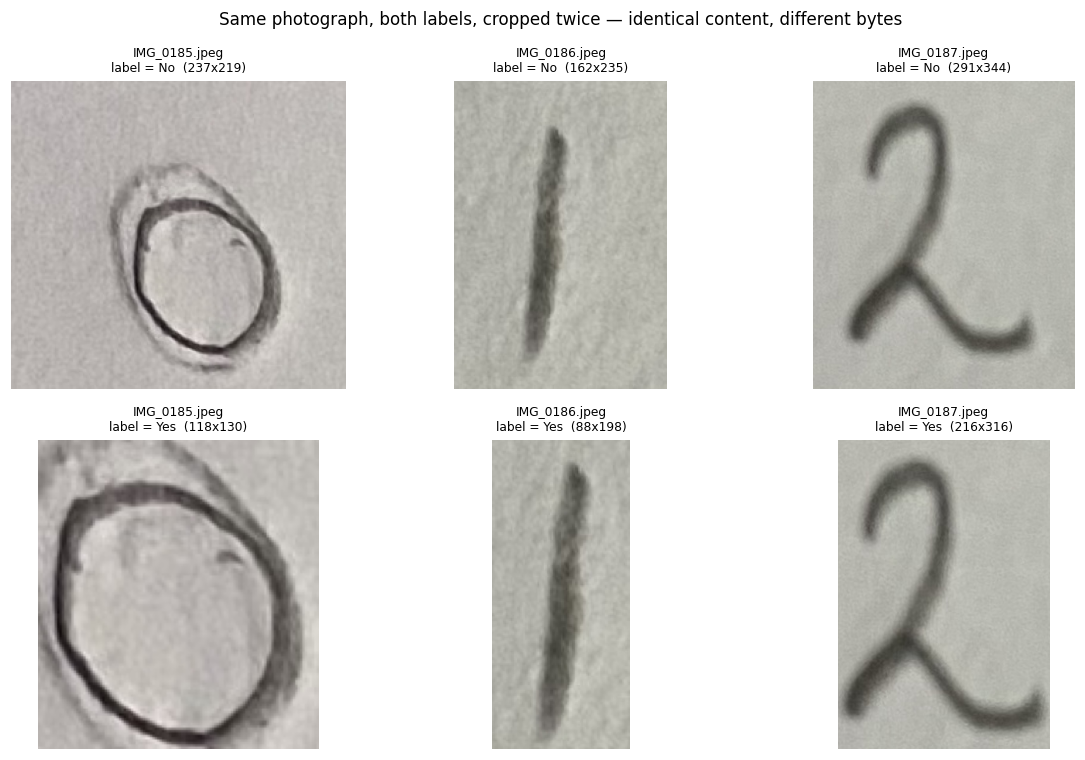

[saved] /content/drive/MyDrive/DyslexAI/results/figures/A_crop_conflict_pairs.png


In [ ]:
conflict_names = sorted(shared)[:3]

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for col, name in enumerate(conflict_names):
    for row, cls in enumerate(['No', 'Yes']):
        r = merged.query('class_label == @cls and original_filename == @name').iloc[0]
        axes[row, col].imshow(Image.open(r['abs_path']))
        axes[row, col].set_title(f'{name}\nlabel = {cls}  ({r["crop_width"]}x{r["crop_height"]})',
                                 fontsize=8)
        axes[row, col].axis('off')

fig.suptitle('Same photograph, both labels, cropped twice — identical content, different bytes',
             fontsize=11)
fig.tight_layout()
fig.savefig(FIG / 'A_crop_conflict_pairs.png', bbox_inches='tight')
plt.show()
print(f'[saved] {FIG / "A_crop_conflict_pairs.png"}')

---
# STAGE 6 — Build the Cropped Metadata Table

This becomes the new source of truth. It carries both the crop's own properties and the
inherited provenance, so Notebook 02 can deduplicate correctly.

In [ ]:
COLUMNS = [
    'sample_id', 'dataset', 'original_filename', 'relative_path', 'abs_path',
    'class_label', 'participant_id', 'script',
    'duplicate_group', 'group_size', 'group_n_classes',
    'is_duplicate_copy', 'is_cross_class_conflict',
    'orig_sha256', 'crop_sha256',
    'orig_width', 'orig_height', 'crop_width', 'crop_height',
    'area_kept', 'orig_aspect', 'crop_aspect', 'distortion',
    'file_size_bytes', 'filename_pattern',
    'capture_time', 'camera_model',
    'split',
]

meta_crop = merged.copy()
meta_crop['sample_id']      = [f'A{i+1:05d}' for i in range(len(meta_crop))]
meta_crop['dataset']        = 'A_cropped'
meta_crop['participant_id'] = 'UNKNOWN'
meta_crop['script']         = 'UNKNOWN'
meta_crop['split']          = 'UNASSIGNED'

meta_crop = meta_crop[COLUMNS]

CROP_META_PATH = INTERIM_DIR / 'dataset_a_cropped_metadata.csv'
meta_crop.to_csv(CROP_META_PATH, index=False)

print(f'[saved] {CROP_META_PATH}  ({len(meta_crop)} rows x {len(meta_crop.columns)} cols)')
print()
print('What Notebook 02 will remove, using the inherited provenance:')
canonical = meta_crop.drop_duplicates('duplicate_group')
print(f'  redundant copies      : {len(meta_crop) - len(canonical)}')
print(f'  conflict groups       : {meta_crop[meta_crop.group_n_classes > 1]["duplicate_group"].nunique()}')
print(f'  files in conflicts    : {int(meta_crop["is_cross_class_conflict"].sum())}')

survivors = (meta_crop[meta_crop['is_cross_class_conflict'] == 0]
             .drop_duplicates('duplicate_group'))
print(f'\n  expected clean total  : {len(survivors)}')
print(survivors['class_label'].value_counts().sort_index().to_string())

[saved] /content/drive/MyDrive/DyslexAI/data/interim/dataset_a_cropped_metadata.csv  (852 rows x 28 cols)

What Notebook 02 will remove, using the inherited provenance:
  redundant copies      : 214
  conflict groups       : 20
  files in conflicts    : 48

  expected clean total  : 618
class_label
No     212
Yes    406


---
# STAGE 7 — Report

In [ ]:
report = f"""
{'='*72}
DATASET A (CROPPED) — VERIFICATION AND PROVENANCE RECOVERY
{'='*72}
Generated : {datetime.now().isoformat(timespec='seconds')}
Jira      : DYS-24, DYS-25, DYS-26

--- CORRESPONDENCE ------------------------------------------------------
{corr.to_string(index=False)}

  One-to-one correspondence verified. No file lost, renamed or added.

--- LOSS OF HASH-BASED DETECTION ----------------------------------------
{comparison.to_string(index=False)}

  Manual cropping changes pixel content, so byte-identical source files are
  no longer byte-identical after cropping. The duplicates remain in the
  dataset; SHA-256 can no longer detect them.

--- PROVENANCE RECOVERY -------------------------------------------------
{recovered.to_string(index=False)}

  Duplicate structure recovered by joining on (class_label, filename)
  against the original audit. All figures match exactly.

--- INDEPENDENT CORROBORATION -------------------------------------------
  copy-pattern filenames in No class : {n_copy_pattern}   (expected 194)
  filenames present in both classes  : {len(shared)}    (expected 20)

  Both derived from cropped filenames alone, without reference to the
  original metadata table.

--- GEOMETRY ------------------------------------------------------------
  area retained   median {merged['area_kept'].median()*100:.1f}%  mean {merged['area_kept'].mean()*100:.1f}%  range {merged['area_kept'].min()*100:.1f}%-{merged['area_kept'].max()*100:.1f}%

  aspect ratio    original {merged['orig_aspect'].min():.2f}-{merged['orig_aspect'].max():.2f}
                  cropped  {merged['crop_aspect'].min():.2f}-{merged['crop_aspect'].max():.2f}

  images stretched >2x by a direct square resize : {(merged['distortion'] > 2).sum()} ({100*(merged['distortion'] > 2).mean():.1f}%)

--- CONSEQUENCE FOR THE PIPELINE ----------------------------------------
  Deduplication MUST use the inherited duplicate_group column, not a hash
  of the cropped file. Running the previous hash-based cleaning on this
  data would report a clean 852-image dataset and silently retain every
  duplicate and every contradictory label.

--- OUTPUT --------------------------------------------------------------
  dataset_a_cropped_metadata.csv   {len(meta_crop)} rows
  expected clean total after dedup and conflict removal : {len(survivors)}
{'='*72}
""".strip()

print(report)
(REPORTS_DIR / 'dataset_a_crop_verification_report.txt').write_text(report)
print(f'\n[saved] {REPORTS_DIR / "dataset_a_crop_verification_report.txt"}')

DATASET A (CROPPED) — VERIFICATION AND PROVENANCE RECOVERY
Generated : 2026-09-26T12:12:40
Jira      : DYS-24, DYS-25, DYS-26

--- CORRESPONDENCE ------------------------------------------------------
class  original_files  cropped_files  missing_from_crop  extra_in_crop
   No             426            426                  0              0
  Yes             426            426                  0              0

  One-to-one correspondence verified. No file lost, renamed or added.

--- LOSS OF HASH-BASED DETECTION ----------------------------------------
                    measure  original  cropped
                      files       852      852
             unique SHA-256       638      852
  redundant copies detected       214        0
cross-class identical files        48        0

  Manual cropping changes pixel content, so byte-identical source files are
  no longer byte-identical after cropping. The duplicates remain in the
  dataset; SHA-256 can no longer detect them.

--- PROVE

---

## What we actually did

1. Verified that all 852 manual crops correspond one-to-one with the original images, by
   filename, with none lost, renamed or added.
2. Hashed every cropped file and **measured** the loss of duplicate detection rather than
   assuming cropping was harmless.
3. Recovered the duplicate structure by joining the crops to the original audit on filename,
   inheriting the recorded group assignments instead of re-deriving them.
4. Corroborated the two headline figures independently from cropped filenames alone.
5. Measured how much area cropping removed and what it did to aspect ratios.
6. Inspected the most aggressive crops visually for clipped strokes and dots.
7. Produced a cropped metadata table carrying provenance forward.

## What we learned

**Cropping made the dataset look clean while leaving every problem in place.** Hash-based
detection found 214 redundant copies and 48 contradictory files before cropping, and zero
afterwards. Nothing was fixed; the detector stopped working.

That is a genuinely useful methodological finding. A data-quality check that stops firing has
not necessarily stopped finding problems — it may have stopped being able to.

**Provenance survived where content did not.** Because filenames were preserved, the structure
was fully recoverable from records. Had the cropping script renamed files, the audit would have
been unrecoverable and the dataset unusable.

**Removing padding traded one cost for another.** Tight crops follow the character's shape, so
aspect ratios became more extreme, and a direct square resize now distorts more than it would
have before.

## What we can tell

> We implemented the manual ROI cropping as requested and verified it against the original
> images. In doing so we found that cropping removes our ability to detect the dataset's
> duplicate and contradictory files by content hash, because hand-drawn crops of identical
> source images are no longer byte-identical. We recovered the structure from the original
> audit through filename provenance and confirmed it by two independent routes. Deduplication
> now runs on recorded provenance rather than on pixel content.

## Requirement this generates for our own dataset

| Problem | Requirement |
|---|---|
| Cropping destroyed content-based duplicate detection | Hash images **at ingest**, before any processing, and store the hash permanently |
| Structure survived only because filenames were kept | Every processing step must preserve a stable identifier linking back to the original capture |
| A quality check silently stopped working | Pipeline checks must assert expected counts, not just report what they find |

---

